<a href="https://colab.research.google.com/github/Rajarajeswari77-ai/Raji/blob/main/Project_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset('titanic')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
# General info
print(df.info())

# Missing values
print("\nMissing values:\n", df.isnull().sum())

# Descriptive statistics for numeric columns
print("\nDescriptive statistics:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing values:
 survived         0
pclass           0
sex              0

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Create a working copy
df_clean = df.copy()

# Fill missing 'age' with median (by sex and pclass for better accuracy)
df_clean['age'] = df_clean.groupby(['sex', 'pclass'])['age'].transform(lambda x: x.fillna(x.median()))

# Fill missing 'embarked' with mode
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

# Drop 'deck' (too many missing) and 'alive' (redundant with survived)
df_clean.drop(columns=['deck', 'alive'], inplace=True)

# Confirm no missing values remain
print("Missing values after cleaning:\n", df_clean.isnull().sum())

Missing values after cleaning:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alone          0
dtype: int64


/tmp/ipykernel_2044/239507349.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)


/tmp/ipykernel_2044/2876702088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='survived', palette='Set2')


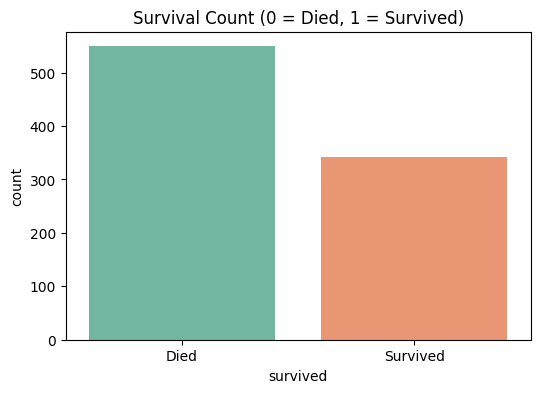

Survival rate: 38.38%


In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='survived', palette='Set2')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xticks([0,1], ['Died', 'Survived'])
plt.show()
print("Survival rate: {:.2f}%".format(df_clean['survived'].mean()*100))

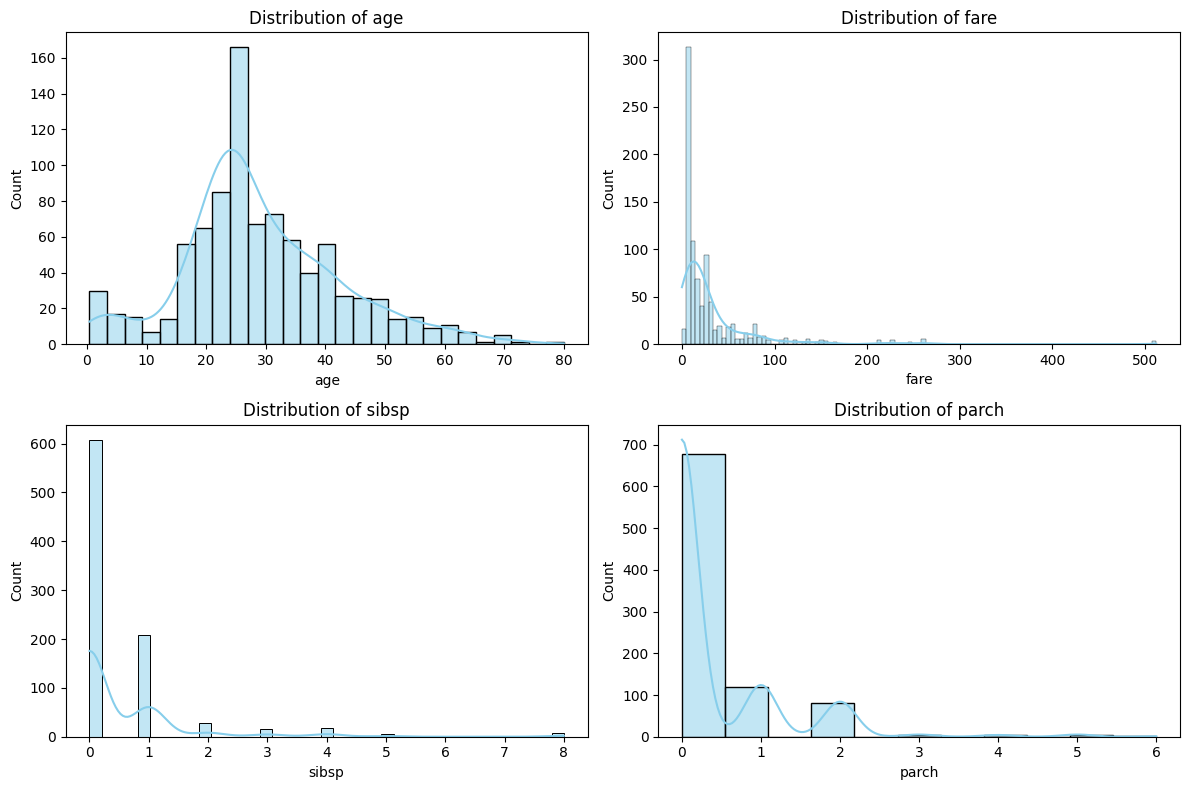

In [5]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
num_cols = ['age', 'fare', 'sibsp', 'parch']
for i, col in enumerate(num_cols):
    row, col_idx = i//2, i%2
    sns.histplot(df_clean[col], kde=True, ax=axes[row, col_idx], color='skyblue')
    axes[row, col_idx].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2044/1960791210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i], palette='pastel')
/tmp/ipykernel_2044/1960791210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i], palette='pastel')
/tmp/ipykernel_2044/1960791210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, ax=axes[i], palette='pastel')


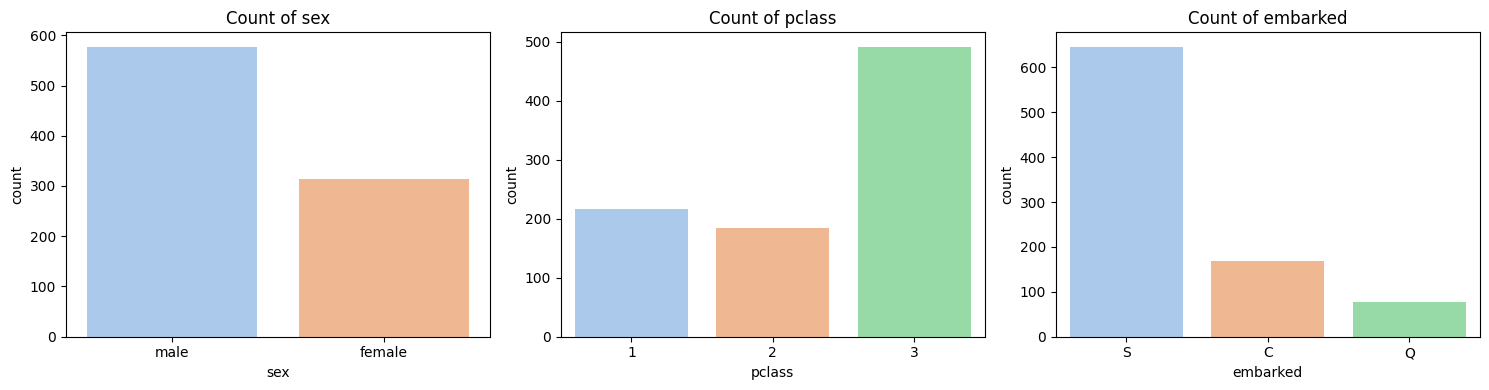

In [6]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
cat_cols = ['sex', 'pclass', 'embarked']
for i, col in enumerate(cat_cols):
    sns.countplot(data=df_clean, x=col, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Count of {col}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2044/3382464443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='sex', y='survived', palette='coolwarm')


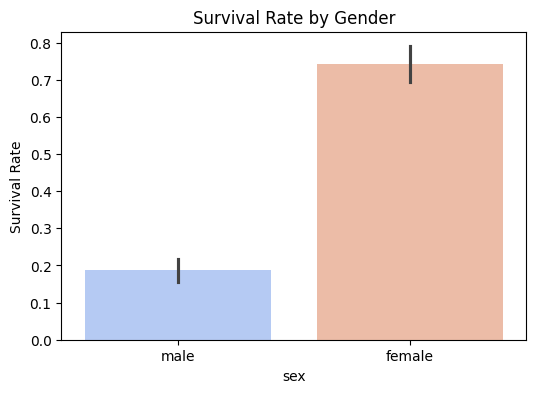

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(data=df_clean, x='sex', y='survived', palette='coolwarm')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

/tmp/ipykernel_2044/1991774356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='pclass', y='survived', palette='viridis')


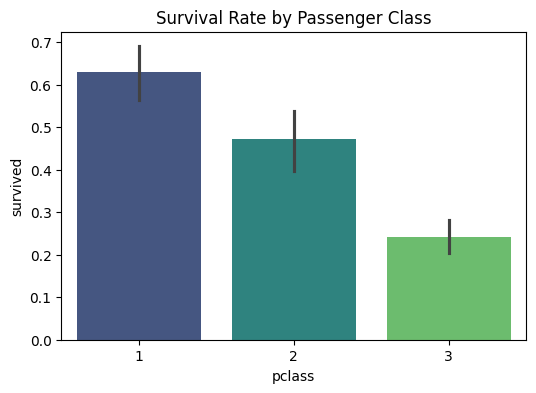

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(data=df_clean, x='pclass', y='survived', palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.show()

/tmp/ipykernel_2044/4241790850.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])


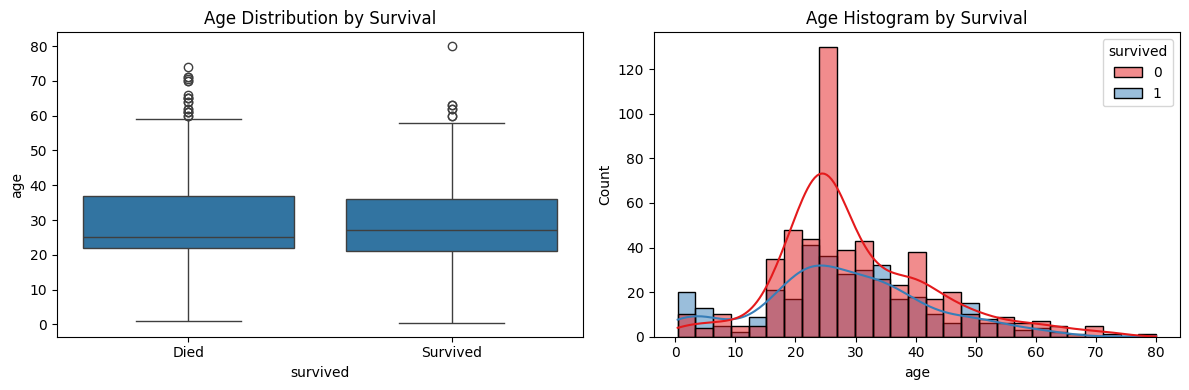

In [9]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(data=df_clean, x='survived', y='age', ax=axes[0])
axes[0].set_xticklabels(['Died', 'Survived'])
axes[0].set_title('Age Distribution by Survival')
sns.histplot(data=df_clean, x='age', hue='survived', kde=True, ax=axes[1], palette='Set1')
axes[1].set_title('Age Histogram by Survival')
plt.tight_layout()
plt.show()

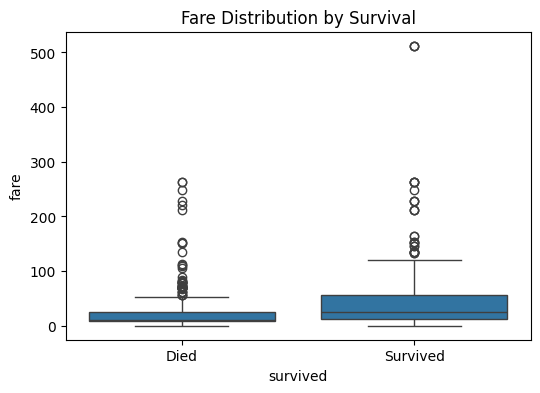

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x='survived', y='fare')
plt.xticks([0,1], ['Died', 'Survived'])
plt.title('Fare Distribution by Survival')
plt.show()

/tmp/ipykernel_2044/3880922032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='embarked', y='survived', palette='muted')


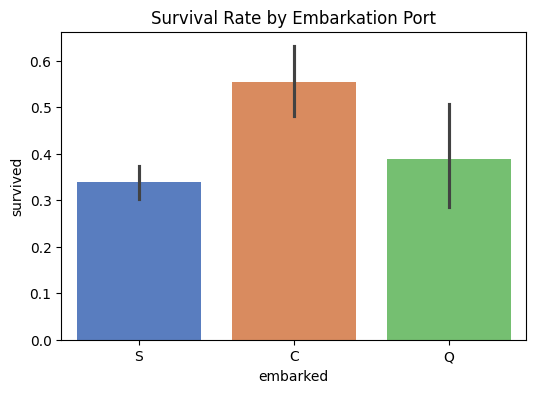

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(data=df_clean, x='embarked', y='survived', palette='muted')
plt.title('Survival Rate by Embarkation Port')
plt.show()

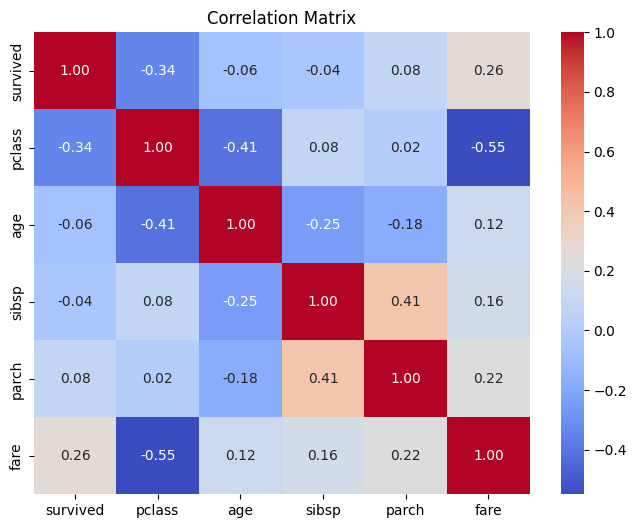

In [12]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

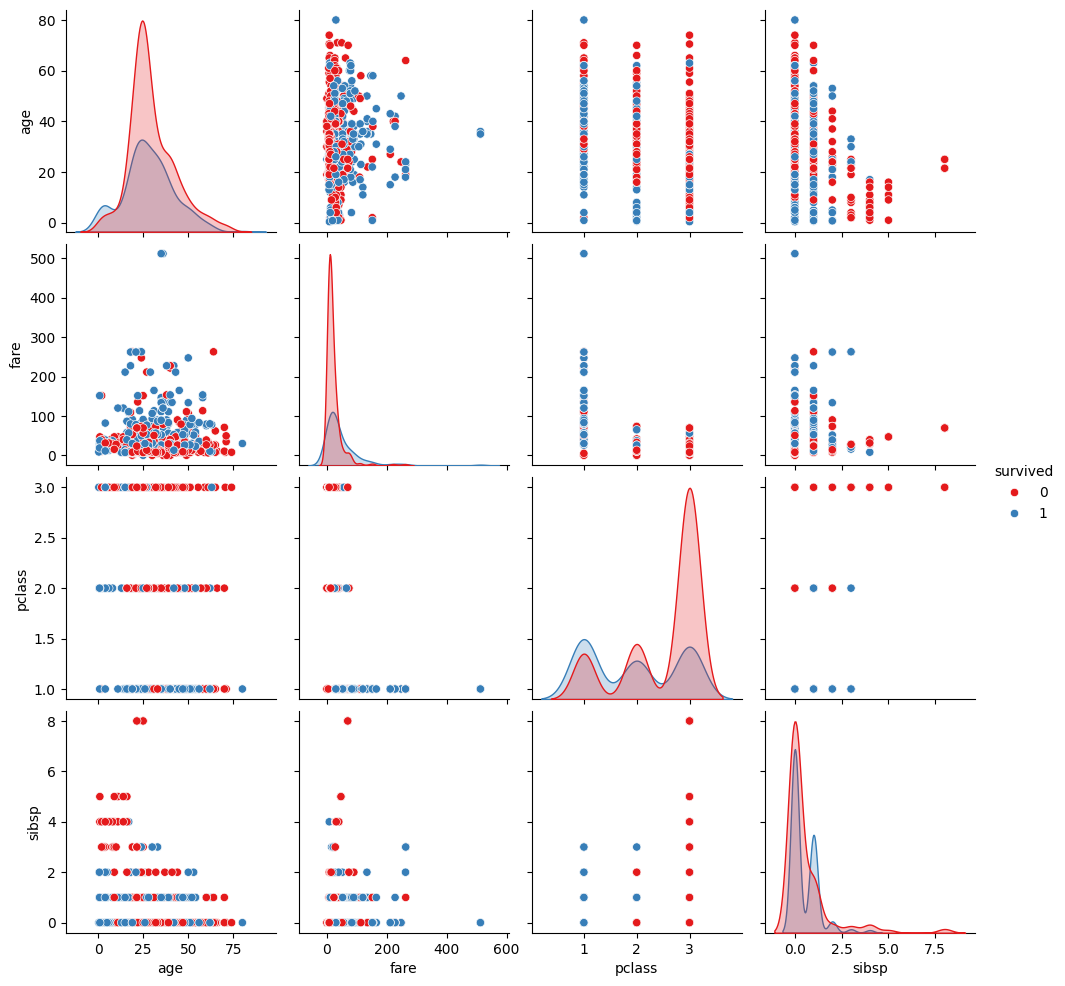

In [13]:
sns.pairplot(df_clean, vars=['age', 'fare', 'pclass', 'sibsp'], hue='survived', palette='Set1')
plt.show()

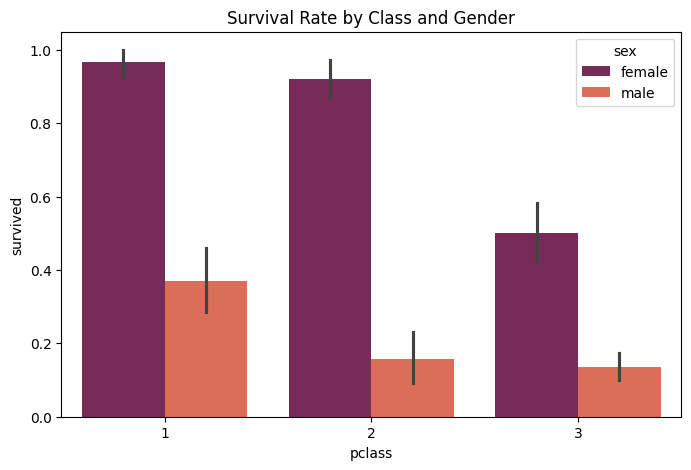

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='pclass', y='survived', hue='sex', palette='rocket')
plt.title('Survival Rate by Class and Gender')
plt.show()

/tmp/ipykernel_2044/820310792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='age_group', y='survived', palette='Blues_d')


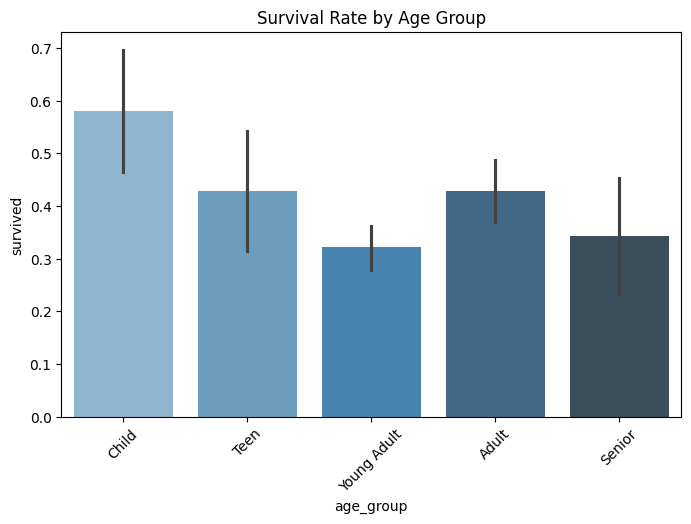

In [15]:
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0,12,18,30,50,100], labels=['Child','Teen','Young Adult','Adult','Senior'])
plt.figure(figsize=(8,5))
sns.barplot(data=df_clean, x='age_group', y='survived', palette='Blues_d')
plt.title('Survival Rate by Age Group')
plt.xticks(rotation=45)
plt.show()

In [16]:
# Group by important features
print("Survival by Gender:\n", df_clean.groupby('sex')['survived'].mean())
print("\nSurvival by Class:\n", df_clean.groupby('pclass')['survived'].mean())
print("\nSurvival by Embarkation:\n", df_clean.groupby('embarked')['survived'].mean())
print("\nSurvival by Age Group:\n", df_clean.groupby('age_group')['survived'].mean())

Survival by Gender:
 sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Survival by Class:
 pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival by Embarkation:
 embarked
C    0.553571
Q    0.389610
S    0.339009
Name: survived, dtype: float64

Survival by Age Group:
 age_group
Child          0.579710
Teen           0.428571
Young Adult    0.321343
Adult          0.428044
Senior         0.343750
Name: survived, dtype: float64


/tmp/ipykernel_2044/3980721130.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\nSurvival by Age Group:\n", df_clean.groupby('age_group')['survived'].mean())


/tmp/ipykernel_2044/4053126090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='sex', y='survived', ax=axes[0,0], palette='coolwarm')
/tmp/ipykernel_2044/4053126090.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='pclass', y='survived', ax=axes[0,1], palette='viridis')
/tmp/ipykernel_2044/4053126090.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Died','Survived'])
/tmp/ipykernel_2044/4053126090.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes

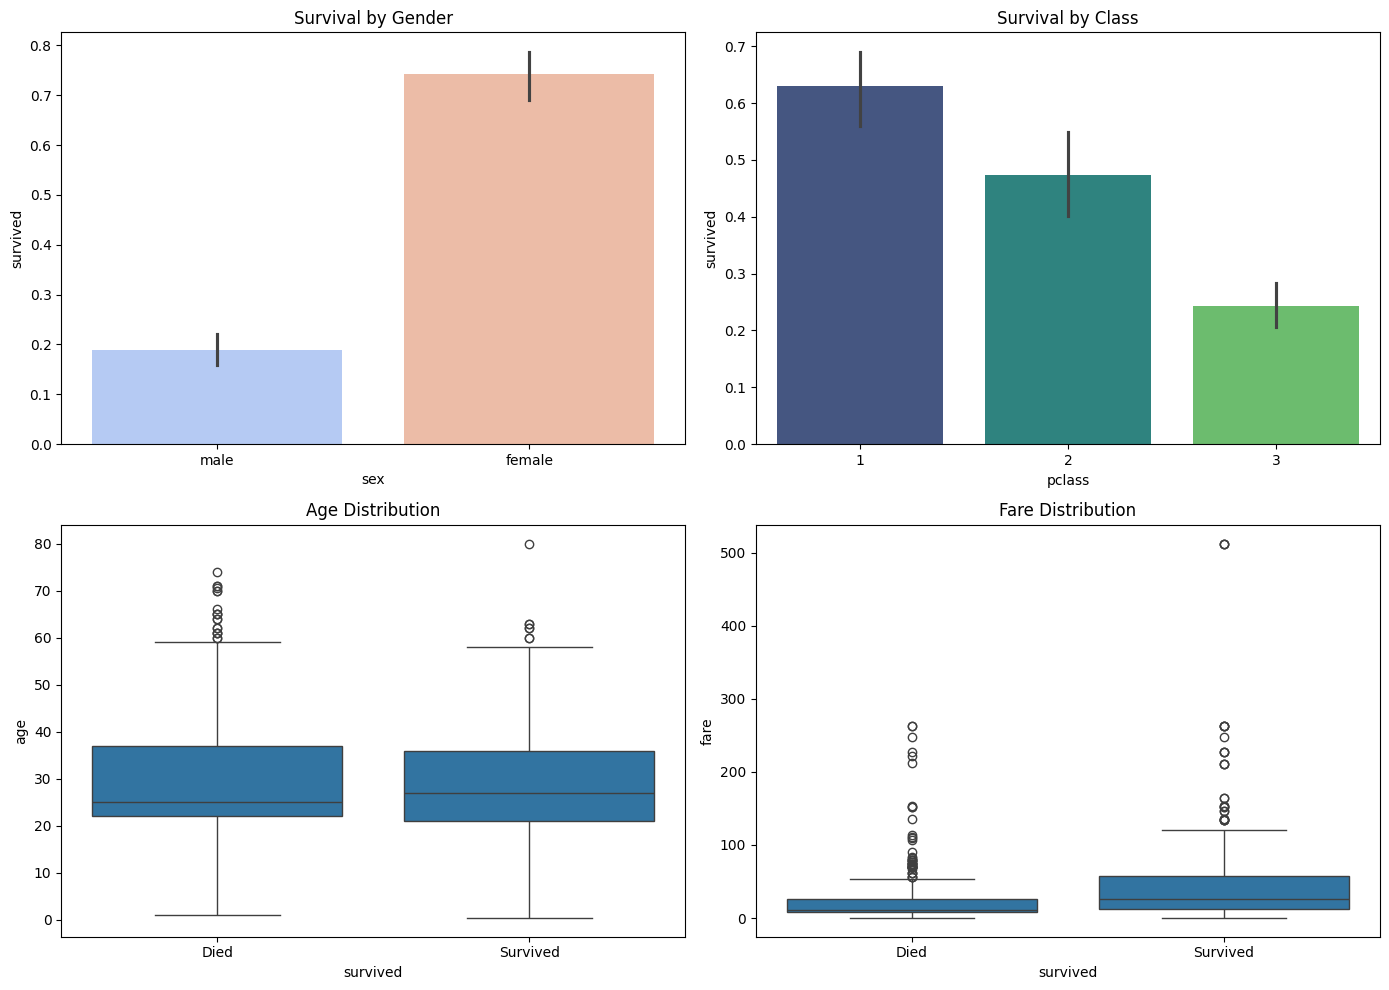

In [17]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
sns.barplot(data=df_clean, x='sex', y='survived', ax=axes[0,0], palette='coolwarm')
axes[0,0].set_title('Survival by Gender')
sns.barplot(data=df_clean, x='pclass', y='survived', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Survival by Class')
sns.boxplot(data=df_clean, x='survived', y='age', ax=axes[1,0])
axes[1,0].set_xticklabels(['Died','Survived'])
axes[1,0].set_title('Age Distribution')
sns.boxplot(data=df_clean, x='survived', y='fare', ax=axes[1,1])
axes[1,1].set_xticklabels(['Died','Survived'])
axes[1,1].set_title('Fare Distribution')
plt.tight_layout()
plt.savefig('eda_key_plots.png', dpi=300)
plt.show()